In [27]:
import pyreadr
import anndata as ad 
import pandas as pd
import numpy as np
import scanpy as sc 
import os
import rpy2.robjects as ro
from rpy2.robjects import default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [3]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [4]:
# load RDS, transpose, and extract names 
readRDS = ro.r["readRDS"]
x = readRDS("M_mat_SmartSVA_corrected.rds")

x_t = ro.r["t"](x)
print(tuple(ro.r["dim"](x_t)))

rownames = list(ro.r["rownames"](x_t))  # sample IDs after transpose
colnames = list(ro.r["colnames"](x_t))  # CpG IDs
print(len(rownames), len(colnames))

(984, 759345)
984 759345


In [5]:
# convert to numpy and build raw AnnData
with localconverter(default_converter + numpy2ri.converter):
    X = np.array(x_t, dtype=np.float32)

adata = ad.AnnData(
    X=X,
    obs=pd.DataFrame(index=pd.Index(rownames, name="sample")),
    var=pd.DataFrame(index=pd.Index(colnames, name="cpg"))
)

print(adata)
print("obs cols:", adata.obs.shape[1])

AnnData object with n_obs × n_vars = 984 × 759345
obs cols: 0


In [6]:
meta = pd.read_excel(
    "endo-me_data/SH-Data Annotation_07.07.20_1.xlsx",
    sheet_name="Batch 1and2",
    dtype=str
)
print(meta.shape)

(1300, 30)


/home/ubuntu/.local/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [7]:
# normalize IDs on both sides 
meta["Epic_Complete Bar code"] = meta["Epic_Complete Bar code"].astype(str).str.strip()
adata.obs_names = adata.obs_names.astype(str).str.strip()

In [8]:
annot = meta.set_index("Epic_Complete Bar code")[[
    "Sample ID",
    "Endometriosis (Yes/No)",
    "Endometriosis stage ",
    "Endometriosis stage grouped (I-II), (III-IV) ",
    "Cycle phase for Analysis",
    "Cycle Phase Source",
]].copy()

annot = annot.rename(columns={
    "Sample ID": "sample-id",
    "Endometriosis (Yes/No)": "endo",
    "Endometriosis stage ": "endo-stage",
    "Endometriosis stage grouped (I-II), (III-IV) ": "endo-stage-grouped",
    "Cycle phase for Analysis": "cycle-phase",
    "Cycle Phase Source": "cycle-phase-source",
})

In [9]:
annot["endo"] = annot["endo"].astype(str).str.strip()
annot = annot[annot["endo"].isin(["Yes", "No"])]

annot["cycle-phase"] = annot["cycle-phase"].astype(str).str.strip()
annot = annot[annot["cycle-phase"] != "Exclude"]

annot["endo"] = annot["endo"].map({"Yes": 1, "No": 0}).astype("Int64")
print("annot rows after filters:", annot.shape[0])

annot rows after filters: 1272


In [10]:
# align samples
common = adata.obs_names.intersection(annot.index)

print("adata samples:", adata.n_obs)
print("annot samples:", annot.shape[0])
print("common samples:", len(common))

adata samples: 984
annot samples: 1272
common samples: 984


In [11]:
adata_final = adata[common].copy()
adata_final.obs = annot.loc[common].copy()

print(adata_final)
print("obs cols:", adata_final.obs.shape[1])
print(adata_final.obs[["endo", "cycle-phase"]].head())

print((adata_final.obs_names == adata_final.obs.index).all())

AnnData object with n_obs × n_vars = 984 × 759345
    obs: 'sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source'
obs cols: 6
                     endo cycle-phase
201904640089_R01C01     1          PE
201904640089_R02C01     0          PE
201904640089_R03C01     1         ESE
201904640089_R04C01     1         MSE
201904640089_R05C01     0          PE
True


In [12]:
# save final file
adata_final.write_h5ad(
    "M_smartsva_corrected_with_SH_annot_filtered.h5ad",
    compression="lzf"
)

#### understanding which phases are considered proliferative vs sercretory 

In [13]:
# Find likely phase columns
[c for c in adata_final.obs.columns if "phase" in c.lower() or "cycle" in c.lower()]

['cycle-phase', 'cycle-phase-source']

In [14]:
phase_col = "cycle-phase"  

phase_counts = adata_final.obs[phase_col].astype(str).value_counts(dropna=False)
print(phase_counts)
print("\nUnique phase labels:")
print(phase_counts.index.tolist())

cycle-phase
PE           473
MSE          209
ESE          122
LSE          108
Menstrual     50
SE            22
Name: count, dtype: int64

Unique phase labels:
['PE', 'MSE', 'ESE', 'LSE', 'Menstrual', 'SE']


In [15]:
adata_binary = adata_final[adata_final.obs[phase_col] != "Menstrual"].copy()

In [16]:
secretory_phases = ["ESE", "MSE", "LSE", "SE"]

adata_binary.obs["phase_binary"] = (
    adata_binary.obs[phase_col]
    .isin(secretory_phases)
    .astype(int)
)

In [17]:
print(adata_binary.obs[phase_col].value_counts())
print(adata_binary.obs["phase_binary"].value_counts())

cycle-phase
PE     473
MSE    209
ESE    122
LSE    108
SE      22
Name: count, dtype: int64
phase_binary
0    473
1    461
Name: count, dtype: int64


In [18]:
X = adata_binary.X
y = adata_binary.obs["phase_binary"].astype(int).values

print(X.shape)
print(y.shape)

(934, 759345)
(934,)


In [19]:
import scipy.sparse as sp

if sp.issparse(X):
    X = X.tocsr()

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(747, 759345) (187, 759345)
(747,) (187,)


### modeling

In [21]:
import scipy.sparse as sp

X = adata_binary.X
y = adata_binary.obs["phase_binary"].astype(int).values

if sp.issparse(X):
    X = X.tocsr()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (934, 759345)
y shape: (934,)


In [22]:
Cs = np.logspace(-6, 2, 25)
all_results = []

for i, C in enumerate(Cs, start=1):
    print(f"\n===== Running C {i}/{len(Cs)}: {C:.3e} =====\n")

    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=C,
            class_weight="balanced",
            max_iter=5000,
            verbose=1
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=4
    )

    print(f"Finished CV for C={C:.3e}")

    pipe.fit(X_train, y_train)
    print(f"Finished full fit for C={C:.3e}")

    train_prob = pipe.predict_proba(X_train)[:, 1]
    test_prob  = pipe.predict_proba(X_test)[:, 1]

    train_pred = (train_prob >= 0.5).astype(int)
    test_pred  = (test_prob >= 0.5).astype(int)

    train_auc = roc_auc_score(y_train, train_prob)
    test_auc  = roc_auc_score(y_test, test_prob)

    train_auprc = average_precision_score(y_train, train_prob)
    test_auprc  = average_precision_score(y_test, test_prob)

    train_precision = precision_score(y_train, train_pred)
    test_precision  = precision_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall  = recall_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1  = f1_score(y_test, test_pred)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc  = accuracy_score(y_test, test_pred)

    all_results.append({
        "penalty": "L2",
        "C": C,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "train_auc": train_auc,
        "test_auc": test_auc,
        "train_auprc": train_auprc,
        "test_auprc": test_auprc,
        "train_precision": train_precision,
        "test_precision": test_precision,
        "train_recall": train_recall,
        "test_recall": test_recall,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "train_acc": train_acc,
        "test_acc": test_acc
    })

    print(
        f"Done C={C:.3e} | "
        f"CV AUC={cv_scores.mean():.3f} ± {cv_scores.std():.3f} | "
        f"Test AUC={test_auc:.3f} | Test AUPRC={test_auprc:.3f}"
    )


===== Running C 1/25: 1.000e-06 =====



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   22.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   23.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   28.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   36.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.6s finished


Finished CV for C=1.000e-06


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   21.0s finished


Finished full fit for C=1.000e-06
Done C=1.000e-06 | CV AUC=0.949 ± 0.020 | Test AUC=0.961 | Test AUPRC=0.966

===== Running C 2/25: 2.154e-06 =====



...

Finished full fit for C=4.642e+01
Done C=4.642e+01 | CV AUC=0.945 ± 0.021 | Test AUC=0.961 | Test AUPRC=0.966

===== Running C 25/25: 1.000e+02 =====



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   21.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   21.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   21.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.0s finished


Finished CV for C=1.000e+02


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.4s finished


Finished full fit for C=1.000e+02
Done C=1.000e+02 | CV AUC=0.945 ± 0.021 | Test AUC=0.960 | Test AUPRC=0.966


In [23]:
ridge_df = pd.DataFrame([
    {
        "C": r["C"],

        "train_auc": r["train_auc"],
        "test_auc": r["test_auc"],

        "train_auprc": r["train_auprc"],
        "test_auprc": r["test_auprc"],

        "train_precision": r["train_precision"],
        "test_precision": r["test_precision"],

        "train_recall": r["train_recall"],
        "test_recall": r["test_recall"],

        "train_f1": r["train_f1"],
        "test_f1": r["test_f1"],

        "train_acc": r["train_acc"],
        "test_acc": r["test_acc"],

        "cv_auc_mean": r["cv_auc_mean"],
        "cv_auc_std": r["cv_auc_std"]
    }
    for r in all_results
    if r["penalty"] == "L2"
]).sort_values("C")

ridge_df

,C,train_auc,test_auc,train_auprc,test_auprc,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_acc,test_acc,cv_auc_mean,cv_auc_std
0,0.000001,0.999606,0.960870,0.999597,0.965943,0.991870,0.962963,0.99187,0.847826,0.991870,0.901734,0.991968,0.909091,0.948953,0.019559
1,0.000002,0.999957,0.966247,0.999956,0.970492,0.997283,0.963415,0.99458,0.858696,0.995929,0.908046,0.995984,0.914439,0.955046,0.018317
2,0.000005,1.000000,0.972654,1.000000,0.975780,1.000000,0.963855,1.00000,0.869565,1.000000,0.914286,1.000000,0.919786,0.959452,0.017259
3,0.000010,1.000000,0.978833,1.000000,0.980582,1.000000,0.964286,1.00000,0.880435,1.000000,0.920455,1.000000,0.925134,0.964250,0.015281
4,0.000022,1.000000,0.983295,1.000000,0.984347,1.000000,0.964286,1.00000,0.880435,1.000000,0.920455,1.000000,0.925134,0.968041,0.013327
5,0.000046,1.000000,0.985355,1.000000,0.986291,1.000000,0.975904,1.00000,0.880435,1.000000,0.925714,1.000000,0.930481,0.970472,0.012324
6,0.000100,1.000000,0.987529,1.000000,0.988330,1.000000,0.987805,1.00000,0.880435,1.000000,0.931034,1.000000,0.935829,0.972049,0.012396
7,0.000215,1.000000,0.988330,1.000000,0.989120,1.000000,0.987805,1.00000,0.880435,1.000000,0.931034,1.000000,0.935829,0.973194,0.011933
8,0.000464,1.000000,0.988902,1.000000,0.989737,1.000000,0.987952,1.00000,0.891304,1.000000,0.937143,1.000000,0.941176,0.973698,0.012172
9,0.001000,1.000000,0.989474,1.000000,0.990264,1.000000,0.987952,1.00000,0.891304,1.000000,0.937143,1.000000,0.941176,0.974306,0.011669


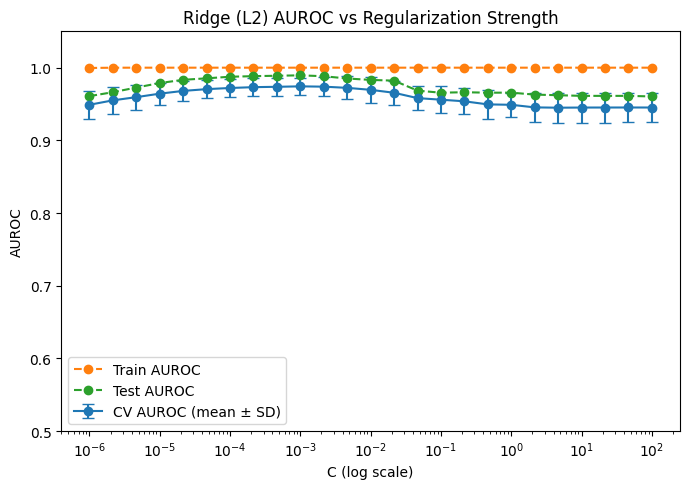

In [28]:
plt.figure(figsize=(7,5))

# CV mean ± SD
plt.errorbar(
    ridge_df["C"],
    ridge_df["cv_auc_mean"],
    yerr=ridge_df["cv_auc_std"],
    fmt="o-",
    capsize=4,
    label="CV AUROC (mean ± SD)"
)

# Train and Test
plt.plot(ridge_df["C"], ridge_df["train_auc"], "o--", label="Train AUROC")
plt.plot(ridge_df["C"], ridge_df["test_auc"],  "o--", label="Test AUROC")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("AUROC")
plt.title("Ridge (L2) AUROC vs Regularization Strength")
plt.ylim(0.5, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

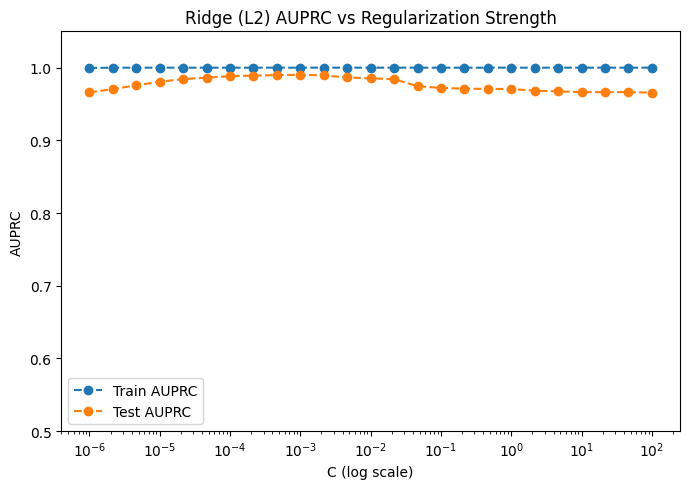

In [29]:
plt.figure(figsize=(7,5))

plt.plot(ridge_df["C"], ridge_df["train_auprc"], "o--", label="Train AUPRC")
plt.plot(ridge_df["C"], ridge_df["test_auprc"],  "o--", label="Test AUPRC")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("AUPRC")
plt.title("Ridge (L2) AUPRC vs Regularization Strength")
plt.ylim(0.5, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

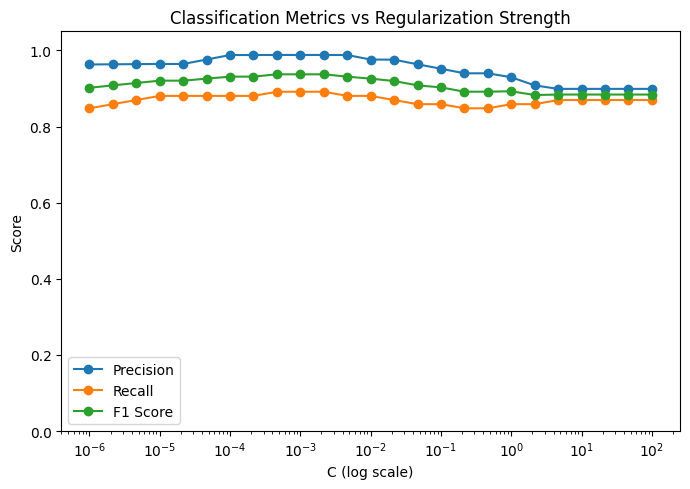

In [30]:
plt.figure(figsize=(7,5))

plt.plot(ridge_df["C"], ridge_df["test_precision"], "o-", label="Precision")
plt.plot(ridge_df["C"], ridge_df["test_recall"], "o-", label="Recall")
plt.plot(ridge_df["C"], ridge_df["test_f1"], "o-", label="F1 Score")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Classification Metrics vs Regularization Strength")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()